In [1]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse import issparse
import rpy2.robjects as ro
import rpy2.robjects.packages as rpackages
from rpy2.robjects import r


## set global random seed =42

In [2]:
sc.settings.seed = 42

In [3]:
%load_ext rpy2.ipython

In [4]:
sample_list = ["S26_17", "S26_18", "S26_19", "S26_20", "S26_22", "S26_23", "S26_27", "S26_31", "S26_32"]

In [5]:
adata_concat_dict =  {}
for sample in sample_list:
    adata_path = f"/projects/circ_iri/work/sc_analysis_final/{sample}_preprocessed.h5ad"
    adata = sc.read_h5ad(adata_path)
    adata_concat_dict[sample] = adata


In [6]:
sample_metadata = {
    "S26_17": {"condition":"Sham_LNP_circGFP"},
    "S26_18": {"condition":"Sham_LNP_circGFP"},
    "S26_19": {"condition":"Sham_LNP_circGFP"},
    "S26_20": {"condition":"IRI_LNP_circGFP"},
    "S26_22": {"condition":"IRI_LNP_circGFP"},
    "S26_23": {"condition":"IRI_LNP_circGFP"},
    "S26_27": {"condition":"IRI_LNP_circINSR"},
    "S26_31": {"condition":"IRI_LNP_circINSR"},
    "S26_32": {"condition":"IRI_LNP_circINSR"},
}

In [7]:
for sample, adata in adata_concat_dict.items():
    adata.obs["sample"] = sample
    for key, value in sample_metadata[sample].items():
        adata.obs[key] = value


In [8]:
adata = ad.concat(
    adata_concat_dict,
    label="sample",  # adds column automatically
    join="outer",  # keeps union of genes
    index_unique="-", 
    merge="first"
)

# Normalization 

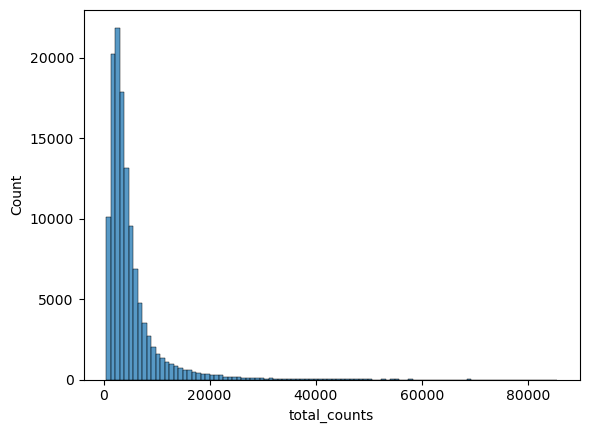

In [9]:
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False)

In [10]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/normalization/histogram_unnormalized_plot.png")

<Figure size 640x480 with 0 Axes>

## Shifted logarithm 

In [11]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

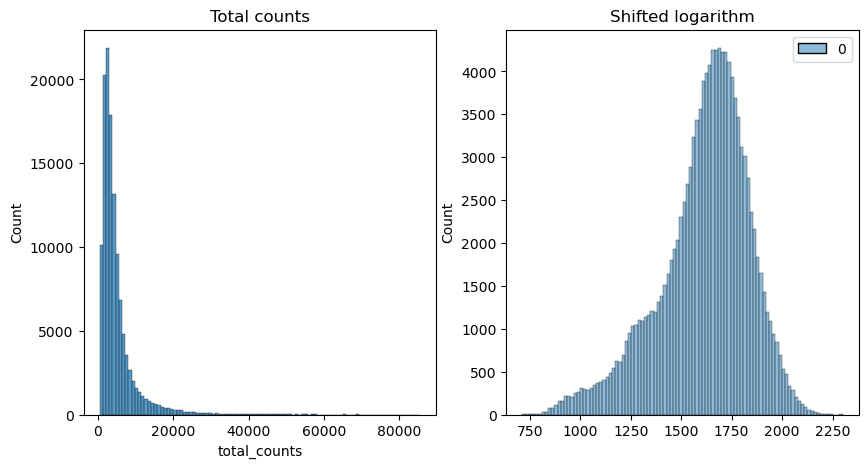

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

In [13]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/normalization/histogram_shifted_logarithm_plot.png")

<Figure size 640x480 with 0 Axes>

## Scran's pooling-based size factor estimation method

In [14]:
%%R
library(scran)
library(BiocParallel)

Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [15]:
# Preliminary clustering for differentiated normalisation
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, n_comps=15)
sc.pp.neighbors(adata_pp)
sc.tl.leiden(
    adata_pp, key_added="groups", flavor="igraph", n_iterations=2, directed=False
)

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
data_mat = adata_pp.X.T
# convert to CSC if possible. See https://github.com/MarioniLab/scran/issues/70
if issparse(data_mat):
    if data_mat.nnz > 2**31 - 1:
        data_mat = data_mat.tocoo()
    else:
        data_mat = data_mat.tocsc()
    # Convert sparse matrix to dense numpy array
    data_mat = data_mat.toarray()

with localconverter(ro.default_converter + numpy2ri.converter):
    ro.globalenv["data_mat"] = data_mat

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv["input_groups"] = adata_pp.obs["groups"]

In [17]:
del adata_pp

In [18]:
%%R -o size_factors

size_factors = sizeFactors(
    computeSumFactors(
        SingleCellExperiment(
            list(counts=data_mat)), 
            clusters = input_groups,
            min.mean = 0.1,
            BPPARAM = MulticoreParam()
    )
)

In [19]:
adata.obs["size_factors"] = size_factors
scran = adata.X / adata.obs["size_factors"].values[:, None]
scran_logged = np.log1p(scran)
adata.layers["scran_normalization"] = csr_matrix(scran_logged)

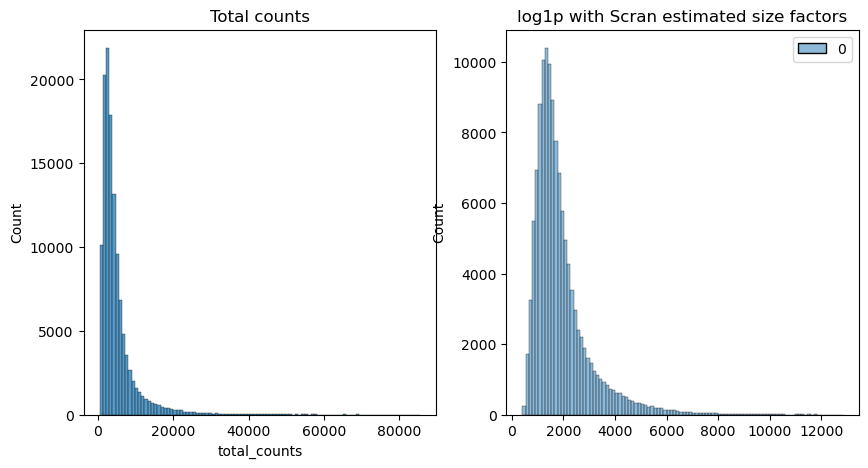

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["scran_normalization"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("log1p with Scran estimated size factors")
plt.show()

In [21]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/normalization/histogram_scran_normalization_plot.png")

<Figure size 640x480 with 0 Axes>

## Analytic Pearson residuals

In [22]:
analytic_pearson = sc.experimental.pp.normalize_pearson_residuals(adata, inplace=False)
adata.layers["analytic_pearson_residuals"] = csr_matrix(analytic_pearson["X"])

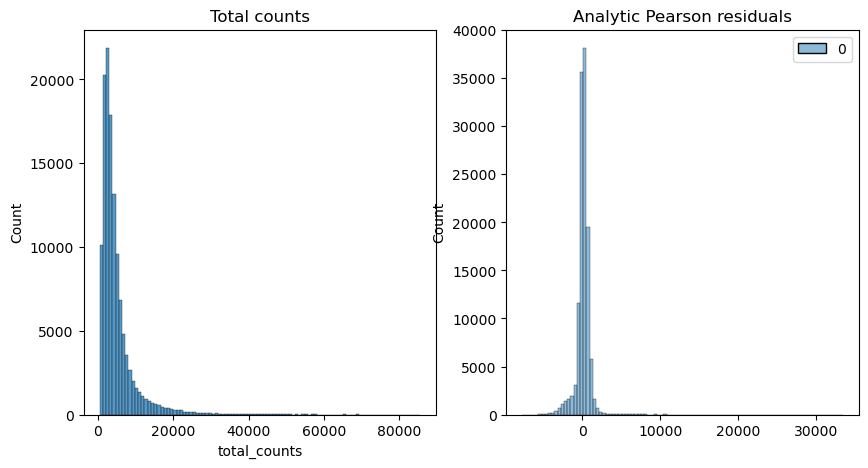

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(
    adata.layers["analytic_pearson_residuals"].sum(1), bins=100, kde=False, ax=axes[1]
)
axes[1].set_title("Analytic Pearson residuals")
plt.show()

In [24]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/normalization/histogram_analytic_pearson_residuals_plot.png")

<Figure size 640x480 with 0 Axes>

In [25]:
# not in general, here possible because gene id and important information were not identified as object and therefore not changed
for col in adata.var.columns:
    if adata.var[col].dtype == "object":
        adata.var[col] = adata.var[col].fillna(False).astype(bool)

/tmp/ipykernel_97006/1856872988.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.var[col] = adata.var[col].fillna(False).astype(bool)
/tmp/ipykernel_97006/1856872988.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  adata.var[col] = adata.var[col].fillna(False).astype(bool)
/tmp/ipykernel_97006/1856872988.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_

In [26]:
adata.write("/projects/circ_iri/work/sc_analysis_final/normalization/adata_concat_normalized.h5ad")

# Feature selection

In [27]:
adata = sc.read_h5ad("/projects/circ_iri/work/sc_analysis_final/normalization/adata_concat_normalized.h5ad", chunk_size = 20000)

In [28]:
%%R
library(scry)
library(SingleCellExperiment)

In [29]:
X_sparse = adata.X.T.tocoo()

Matrix = rpackages.importr("Matrix")

with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    ro.globalenv["obs"] = adata.obs
    ro.globalenv["var"] = adata.var

i, j = X_sparse.row, X_sparse.col
x = X_sparse.data

ro.globalenv["i"] = ro.IntVector((i + 1).tolist())  # R is 1-indexed
ro.globalenv["j"] = ro.IntVector((j + 1).tolist())
ro.globalenv["x"] = ro.FloatVector(x.tolist())

r("X <- sparseMatrix(i = i, j = j, x = x, dims = c({}, {}))".format(*X_sparse.shape))

In [30]:
%%R
print(dim(X))
print(dim(obs))
print(dim(var))


[1]  20681 124646
[1] 124646     26
[1] 20681    13


In [31]:
%%R
sce <- SingleCellExperiment(
  assays = list(X = X),
  colData = obs,
  rowData = var
)



In [32]:
%%R
sce <- devianceFeatureSelection(sce, assay = "X")

In [33]:
with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    binomial_deviance = ro.r("rowData(sce)$binomial_deviance")

In [34]:
idx = binomial_deviance.argsort()[-4000:]
mask = np.zeros(adata.var_names.shape, dtype=bool)
mask[idx] = True

adata.var["highly_deviant"] = mask
adata.var["binomial_deviance"] = binomial_deviance

In [35]:
sc.pp.highly_variable_genes(adata, layer="scran_normalization", batch_key = "sample")

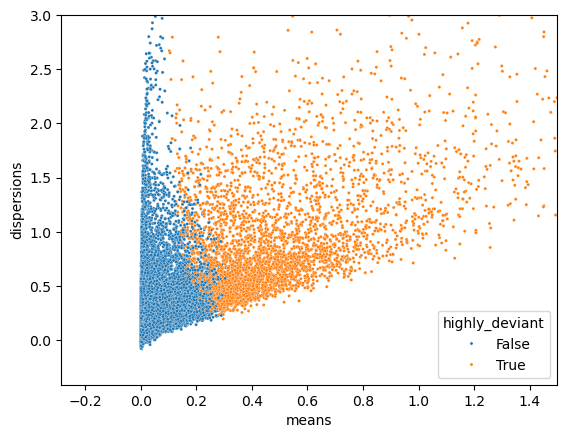

In [36]:
ax = sns.scatterplot(
    data=adata.var, x="means", y="dispersions", hue="highly_deviant", s=5
)
ax.set_xlim(None, 1.5)
ax.set_ylim(None, 3)
plt.show()

In [37]:
plt.savefig("/projects/circ_iri/work/sc_analysis_final/feature_selection/feature_selection_plot.png")

<Figure size 640x480 with 0 Axes>

In [38]:
adata.var["highly_deviant"].sum()

np.int64(4000)

In [39]:
adata.write("/projects/circ_iri/work/sc_analysis_final/feature_selection/adata_concat_feature_selection.h5ad")